# Improving the Baseline Model

## Introduction

The baseline Random Forest model achieved **100% training accuracy** but only **50% testing accuracy**, indicating severe overfitting. Rather than replacing the original model, this notebook continues the project by following the iterative machine learning engineering process.

The goal is to improve model generalization through additional data preprocessing, feature selection, hyperparameter tuning, and cross-validation. The results will be compared with the baseline model to evaluate whether these improvements reduce overfitting and produce a more reliable classifier.


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import learning_curve

# plt.figure(figsize=(8, 5))
sns.set_palette("Paired")

#### Data
Instead of starting from 0, I start with merged data from previous notebook

In [2]:
data = pd.read_csv('/Users/gabrielaslomiany/GIT/Alzheimer Detection/merged.csv')
data.head()

,RID,Test_data_x,Diagnosis,FDG_PET,Test_data_y,CDRSB,ADAS11,ADAS13,MMSE,RAVLT_immediate,...,Cortical Thickness Standard Deviation of RightLingual,Volume (Cortical Parcellation) of RightMedialOrbitofrontal,Surface Area of RightMedialOrbitofrontal,Cortical Thickness Average of RightMedialOrbitofrontal,Cortical Thickness Standard Deviation of RightMedialOrbitofrontal,Volume (Cortical Parcellation) of RightMiddleTemporal,Surface Area of RightMiddleTemporal,Cortical Thickness Average of RightMiddleTemporal,Cortical Thickness Standard Deviation of RightMiddleTemporal,Volume (WM Parcellation) of FourthVentricle
0,2,0,CN,"1,36926",0,0,"10,67","18,67",28,44.0,...,"0,694",3835,1622,"2,077","0,746",15683,4272,"3,028","0,649",4396
1,3,0,AD,"1,09079",0,"4,5",22,31,20,22.0,...,"0,591",3681,1734,"1,942","0,696",10387,3316,"2,545","0,686",3304
2,4,1,LMCI,NaN,1,1,"14,33","21,33",27,37.0,...,"0,588",4060,1728,"2,18","0,607",11156,3598,"2,67","0,631",1338
3,5,0,CN,"1,29799",0,0,"8,67","14,67",29,37.0,...,"0,628",5180,1868,"2,543","0,709",11579,3387,"2,911","0,66",1623
4,6,0,LMCI,NaN,0,"0,5","18,67","25,67",25,30.0,...,"0,631",3078,1241,"2,141","0,701",9641,2781,"2,9","0,727",1035


In [3]:
# Columns to keep
columns_to_keep = [
    # Target
    "Diagnosis",

    # Demographics
    "Age", "Gender", "Year_education", "Ethnicity", "Race", "Marital_status", "High_risk_ApoE4",

    # Cognitive tests
    "FDG_PET", "CDRSB", "ADAS11", "ADAS13", "MMSE", "RAVLT_immediate", "RAVLT_learning", "RAVLT_forgetting", "RAVLT_perc_forgetting",

    # Global MRI biomarkers
    "Ventricles", "Hippocampus", "WholeBrain", "Entorhinal", "Fusiform", "MidTemp", "Intra cranial volume",

    # MRI regional volumes
    "Volume (WM Parcellation) of LeftHippocampus",
    "Volume (WM Parcellation) of RightHippocampus",
    "Volume (Cortical Parcellation) of LeftEntorhinal",
    "Volume (Cortical Parcellation) of RightEntorhinal",
    "Volume (Cortical Parcellation) of LeftFusiform",
    "Volume (Cortical Parcellation) of RightFusiform",
    "Volume (Cortical Parcellation) of LeftMiddleTemporal",
    "Volume (Cortical Parcellation) of RightMiddleTemporal",
    "Volume (Cortical Parcellation) of LeftInferiorTemporal",
    "Volume (Cortical Parcellation) of RightInferiorTemporal",
    "Volume (Cortical Parcellation) of LeftParahippocampal",
    "Volume (Cortical Parcellation) of RightParahippocampal",
    "Volume (Cortical Parcellation) of LeftPosteriorCingulate",
    "Volume (Cortical Parcellation) of RightPosteriorCingulate",
    "Volume (Cortical Parcellation) of LeftPrecuneus",
    "Volume (Cortical Parcellation) of RightPrecuneus",
    "Volume (Cortical Parcellation) of LeftInferiorParietal",
    "Volume (Cortical Parcellation) of RightInferiorParietal",
    "Volume (Cortical Parcellation) of LeftSuperiorTemporal",
    "Volume (Cortical Parcellation) of RightSuperiorTemporal",
    "Volume (Cortical Parcellation) of LeftTemporalPole",
    "Volume (Cortical Parcellation) of RightTemporalPole",
    "Volume (WM Parcellation) of LeftAmygdala",
    "Volume (WM Parcellation) of RightAmygdala",
    "Volume (WM Parcellation) of LeftThalamus",
    "Volume (WM Parcellation) of RightThalamus",
    "Volume (WM Parcellation) of LeftCaudate",
    "Volume (WM Parcellation) of RightCaudate",
    "Volume (WM Parcellation) of LeftPutamen",
    "Volume (WM Parcellation) of RightPutamen",
    "Volume (WM Parcellation) of LeftPallidum",
    "Volume (WM Parcellation) of RightPallidum",
    "Volume (WM Parcellation) of LeftAccumbensArea",
    "Volume (WM Parcellation) of RightAccumbensArea",
    "Volume (WM Parcellation) of LeftLateralVentricle",
    "Volume (WM Parcellation) of RightLateralVentricle",
    "Volume (WM Parcellation) of LeftInferiorLateralVentricle",
    "Volume (WM Parcellation) of RightInferiorLateralVentricle",
    "Volume (WM Parcellation) of ThirdVentricle",
    "Volume (Cortical Parcellation) of Icv"
]

# Create a new dataframe
df = data.loc[:, columns_to_keep].copy()

print(df.shape)
df.head()

(1158, 64)


,Diagnosis,Age,Gender,Year_education,Ethnicity,Race,Marital_status,High_risk_ApoE4,FDG_PET,CDRSB,...,Volume (WM Parcellation) of LeftPallidum,Volume (WM Parcellation) of RightPallidum,Volume (WM Parcellation) of LeftAccumbensArea,Volume (WM Parcellation) of RightAccumbensArea,Volume (WM Parcellation) of LeftLateralVentricle,Volume (WM Parcellation) of RightLateralVentricle,Volume (WM Parcellation) of LeftInferiorLateralVentricle,Volume (WM Parcellation) of RightInferiorLateralVentricle,Volume (WM Parcellation) of ThirdVentricle,Volume (Cortical Parcellation) of Icv
0,CN,"74,3",Male,16,Not Hisp/Latino,White,Married,0.0,"1,36926",0,...,1621,1602,524,465,57742,55425,2630,2436,3644,1984660
1,AD,"81,3",Male,18,Not Hisp/Latino,White,Married,1.0,"1,09079","4,5",...,1656,1692,673,585,43635,28743,6300,5921,3155,1920690
2,LMCI,"67,5",Male,10,Hisp/Latino,White,Married,0.0,NaN,1,...,1632,1575,481,551,19569,18952,604,480,1336,1679440
3,CN,"73,7",Male,16,Not Hisp/Latino,White,Married,0.0,"1,29799",0,...,1650,1578,505,605,16154,16620,923,365,1548,1640770
4,LMCI,"80,4",Female,13,Not Hisp/Latino,White,Married,0.0,NaN,"0,5",...,1423,1245,358,448,20164,18023,713,926,2651,1485830


In [4]:
df.dtypes

Diagnosis                                                      str
Age                                                            str
Gender                                                         str
Year_education                                               int64
Ethnicity                                                      str
                                                             ...  
Volume (WM Parcellation) of RightLateralVentricle              str
Volume (WM Parcellation) of LeftInferiorLateralVentricle       str
Volume (WM Parcellation) of RightInferiorLateralVentricle      str
Volume (WM Parcellation) of ThirdVentricle                     str
Volume (Cortical Parcellation) of Icv                          str
Length: 64, dtype: object

In [5]:
numeric_string_cols = [
    "Age",
    "FDG_PET",
    "CDRSB",
    "ADAS11",
    "ADAS13",
    "RAVLT_perc_forgetting",

    "Volume (WM Parcellation) of LeftHippocampus",
    "Volume (WM Parcellation) of RightHippocampus",

    "Volume (Cortical Parcellation) of LeftEntorhinal",
    "Volume (Cortical Parcellation) of RightEntorhinal",

    "Volume (Cortical Parcellation) of LeftFusiform",
    "Volume (Cortical Parcellation) of RightFusiform",

    "Volume (Cortical Parcellation) of LeftMiddleTemporal",
    "Volume (Cortical Parcellation) of RightMiddleTemporal",

    "Volume (Cortical Parcellation) of LeftInferiorTemporal",
    "Volume (Cortical Parcellation) of RightInferiorTemporal",

    "Volume (Cortical Parcellation) of LeftParahippocampal",
    "Volume (Cortical Parcellation) of RightParahippocampal",

    "Volume (Cortical Parcellation) of LeftPosteriorCingulate",
    "Volume (Cortical Parcellation) of RightPosteriorCingulate",

    "Volume (Cortical Parcellation) of LeftPrecuneus",
    "Volume (Cortical Parcellation) of RightPrecuneus",

    "Volume (Cortical Parcellation) of LeftInferiorParietal",
    "Volume (Cortical Parcellation) of RightInferiorParietal",

    "Volume (Cortical Parcellation) of LeftSuperiorTemporal",
    "Volume (Cortical Parcellation) of RightSuperiorTemporal",

    "Volume (Cortical Parcellation) of LeftTemporalPole",
    "Volume (Cortical Parcellation) of RightTemporalPole",

    "Volume (WM Parcellation) of LeftAmygdala",
    "Volume (WM Parcellation) of RightAmygdala",

    "Volume (WM Parcellation) of LeftThalamus",
    "Volume (WM Parcellation) of RightThalamus",

    "Volume (WM Parcellation) of LeftCaudate",
    "Volume (WM Parcellation) of RightCaudate",

    "Volume (WM Parcellation) of LeftPutamen",
    "Volume (WM Parcellation) of RightPutamen",

    "Volume (WM Parcellation) of LeftPallidum",
    "Volume (WM Parcellation) of RightPallidum",

    "Volume (WM Parcellation) of LeftAccumbensArea",
    "Volume (WM Parcellation) of RightAccumbensArea",

    "Volume (WM Parcellation) of LeftLateralVentricle",
    "Volume (WM Parcellation) of RightLateralVentricle",

    "Volume (WM Parcellation) of LeftInferiorLateralVentricle",
    "Volume (WM Parcellation) of RightInferiorLateralVentricle",

    "Volume (WM Parcellation) of ThirdVentricle",

    "Volume (Cortical Parcellation) of Icv",
]



In [6]:
for col in numeric_string_cols:
    if (df[col].astype(str).str.strip() == "").any():
        print(col)

Volume (WM Parcellation) of LeftHippocampus
Volume (WM Parcellation) of RightHippocampus
Volume (Cortical Parcellation) of LeftEntorhinal
Volume (Cortical Parcellation) of RightEntorhinal
Volume (Cortical Parcellation) of LeftFusiform
Volume (Cortical Parcellation) of RightFusiform
Volume (Cortical Parcellation) of LeftMiddleTemporal
Volume (Cortical Parcellation) of RightMiddleTemporal
Volume (Cortical Parcellation) of LeftInferiorTemporal
Volume (Cortical Parcellation) of RightInferiorTemporal
Volume (Cortical Parcellation) of LeftParahippocampal
Volume (Cortical Parcellation) of RightParahippocampal
Volume (Cortical Parcellation) of LeftPosteriorCingulate
Volume (Cortical Parcellation) of RightPosteriorCingulate
Volume (Cortical Parcellation) of LeftPrecuneus
Volume (Cortical Parcellation) of RightPrecuneus
Volume (Cortical Parcellation) of LeftInferiorParietal
Volume (Cortical Parcellation) of RightInferiorParietal
Volume (Cortical Parcellation) of LeftSuperiorTemporal
Volume (Cort

In [7]:
for col in numeric_string_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .replace("", np.nan)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

In [8]:
df["FDG_PET"] = df["FDG_PET"].fillna(df["FDG_PET"].mean())

In [9]:
df = df.dropna()
df.isna().sum()

Diagnosis                                                    0
Age                                                          0
Gender                                                       0
Year_education                                               0
Ethnicity                                                    0
                                                            ..
Volume (WM Parcellation) of RightLateralVentricle            0
Volume (WM Parcellation) of LeftInferiorLateralVentricle     0
Volume (WM Parcellation) of RightInferiorLateralVentricle    0
Volume (WM Parcellation) of ThirdVentricle                   0
Volume (Cortical Parcellation) of Icv                        0
Length: 64, dtype: int64

In [37]:
X = df.drop(columns="Diagnosis")
y = df["Diagnosis"]

diagnosis_mapping = {
    "CN": 0,
    "SMC": 1,
    "EMCI": 2,
    "LMCI": 3,
    "AD": 4
}

y = df["Diagnosis"].map(diagnosis_mapping)
y.head()

0    0
1    4
2    3
3    0
4    3
Name: Diagnosis, dtype: int64

In [11]:
print(df["Diagnosis"].value_counts(dropna=False))

Diagnosis
LMCI    406
CN      308
AD      198
EMCI    185
SMC      60
Name: count, dtype: int64


In [12]:
print(df["FDG_PET"].isna().sum())

0


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
print(type(X_train))
print(type(X_test))

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [22]:
X_train.head()

,Age,Gender,Year_education,Ethnicity,Race,Marital_status,High_risk_ApoE4,FDG_PET,CDRSB,ADAS11,...,Volume (WM Parcellation) of LeftPallidum,Volume (WM Parcellation) of RightPallidum,Volume (WM Parcellation) of LeftAccumbensArea,Volume (WM Parcellation) of RightAccumbensArea,Volume (WM Parcellation) of LeftLateralVentricle,Volume (WM Parcellation) of RightLateralVentricle,Volume (WM Parcellation) of LeftInferiorLateralVentricle,Volume (WM Parcellation) of RightInferiorLateralVentricle,Volume (WM Parcellation) of ThirdVentricle,Volume (Cortical Parcellation) of Icv
380,63.9,Male,13,Not Hisp/Latino,White,Married,1.0,1.23183,3.5,12.00,...,1595.0,1409.0,462.0,470.0,26363.0,25996.0,1880.0,1991.0,2811.0,1833650.0
680,68.8,Male,16,Not Hisp/Latino,White,Married,1.0,1.24985,1.0,9.00,...,1579.0,1243.0,382.0,585.0,13805.0,9303.0,476.0,276.0,1066.0,1454560.0
1140,76.8,Male,16,Not Hisp/Latino,White,Married,0.0,1.32417,0.0,9.00,...,1488.0,1399.0,361.0,407.0,19305.0,17122.0,1180.0,425.0,1369.0,1571500.0
441,64.3,Male,16,Not Hisp/Latino,Black,Married,1.0,1.30378,1.0,7.00,...,1901.0,1921.0,494.0,492.0,30547.0,28929.0,1248.0,1045.0,1669.0,1816740.0
459,73.9,Female,12,Not Hisp/Latino,White,Widowed,1.0,1.23183,2.0,9.33,...,1306.0,1268.0,338.0,320.0,22326.0,23450.0,1541.0,1314.0,2068.0,1438180.0


In [15]:
categorical_cols = [
    "Gender",
    "Ethnicity",
    "Race",
    "Marital_status",
]

In [34]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

In [17]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(925, 17)
(232, 17)


In [18]:
print(encoder.get_feature_names_out(categorical_cols))

['Gender_Female' 'Gender_Male' 'Ethnicity_Hisp/Latino'
 'Ethnicity_Not Hisp/Latino' 'Ethnicity_Unknown' 'Race_Am Indian/Alaskan'
 'Race_Asian' 'Race_Black' 'Race_Hawaiian/Other PI' 'Race_More than one'
 'Race_Unknown' 'Race_White' 'Marital_status_Divorced'
 'Marital_status_Married' 'Marital_status_Never married'
 'Marital_status_Unknown' 'Marital_status_Widowed']


In [19]:
encoded_df = pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out(categorical_cols))
encoded_df.head()

,Gender_Female,Gender_Male,Ethnicity_Hisp/Latino,Ethnicity_Not Hisp/Latino,Ethnicity_Unknown,Race_Am Indian/Alaskan,Race_Asian,Race_Black,Race_Hawaiian/Other PI,Race_More than one,Race_Unknown,Race_White,Marital_status_Divorced,Marital_status_Married,Marital_status_Never married,Marital_status_Unknown,Marital_status_Widowed
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [20]:
print(type(X_train))
print(type(X_train_encoded))

<class 'pandas.DataFrame'>
<class 'numpy.ndarray'>


Change encoded to pandas dataframe

In [26]:
X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out(categorical_cols), index=X_train.index,)

X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoder.get_feature_names_out(categorical_cols),
index=X_test.index,)

print(type(X_train_encoded))
print(type(X_test_encoded))

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [27]:
# dropping categorical columns from the basic X_train and X-test to later replace it with the encoded
X_train_numeric = X_train.drop(columns=categorical_cols)
X_test_numeric = X_test.drop(columns=categorical_cols)

In [30]:
X_train_prepared = pd.concat([X_train_numeric, X_train_encoded], axis=1,)

X_test_prepared = pd.concat([X_test_numeric, X_test_encoded], axis=1,)

In [31]:
# basic X_test and cat col are now replaced with encoded
X_test_prepared.head()

,Age,Year_education,High_risk_ApoE4,FDG_PET,CDRSB,ADAS11,ADAS13,MMSE,RAVLT_immediate,RAVLT_learning,...,Race_Black,Race_Hawaiian/Other PI,Race_More than one,Race_Unknown,Race_White,Marital_status_Divorced,Marital_status_Married,Marital_status_Never married,Marital_status_Unknown,Marital_status_Widowed
550,77.3,17,2.0,1.10489,0.5,11.33,20.33,28,30.0,5.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
366,74.5,19,0.0,1.05429,5.0,14.00,25.00,26,19.0,-1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
254,82.7,16,0.0,1.23183,0.0,4.00,6.00,29,39.0,7.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
655,75.8,16,1.0,1.30998,0.5,13.00,20.00,26,40.0,5.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,73.7,16,0.0,1.29799,0.0,8.67,14.67,29,37.0,4.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [38]:
y.head()

0    0
1    4
2    3
3    0
4    3
Name: Diagnosis, dtype: int64

## Model training

In [39]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_prepared, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [41]:
y_train_pred = model.predict(X_train_prepared)
y_test_pred = model.predict(X_test_prepared)

In [46]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2%}")
print(f"Testing Accuracy: {test_accuracy:.2%}")

Training Accuracy: 100.00%
Testing Accuracy: 80.60%


In [57]:
print(classification_report(y_test, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.82      0.95      0.88        62
           1       0.00      0.00      0.00        12
           2       0.74      0.62      0.68        37
           3       0.76      0.90      0.82        81
           4       0.97      0.80      0.88        40

    accuracy                           0.81       232
   macro avg       0.66      0.65      0.65       232
weighted avg       0.77      0.81      0.78       232



In [56]:
print(pd.Series(y_test_pred).value_counts())

3    96
0    72
4    33
2    31
Name: count, dtype: int64


Model doesn not predict class 1.

Mapping:</br> 0 = CN</br>
1 = SMC</br>
2 = EMCI</br>
3 = LMCI</br>
4 = AD</br>


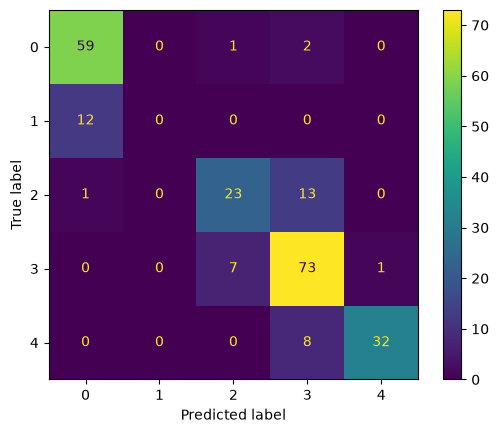

In [61]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)

The confusion matrix shows that the model correctly classifies most samples belonging to the CN, LMCI, and AD classes. However, it struggles to identify the SMC class, as no samples from this category were predicted correctly. This suggests that the minority class is difficult to distinguish from the remaining diagnostic groups and may benefit from additional feature engineering, class balancing techniques, or hyperparameter tuning.

##### Checking feature importance

In [53]:
feature_importance = (
    pd.DataFrame({
        "Feature": X_train_prepared.columns,
        "Importance": model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

feature_importance.head(20)

,Feature,Importance
4,CDRSB,0.169557
7,MMSE,0.061333
6,ADAS13,0.058789
5,ADAS11,0.038781
8,RAVLT_immediate,0.029765
11,RAVLT_perc_forgetting,0.021904
3,FDG_PET,0.021541
34,Volume (Cortical Parcellation) of RightPrecuneus,0.021082
9,RAVLT_learning,0.020442
0,Age,0.018764


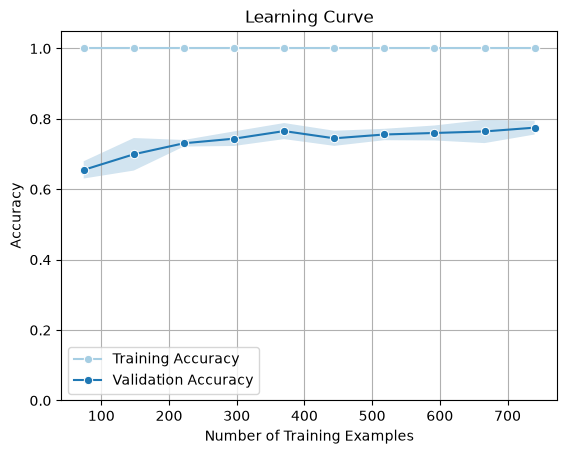

In [60]:
# Compute learning curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=RandomForestClassifier(random_state=42, n_estimators=100),
    X=X_train_prepared,
    y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42,
    n_jobs=1
)

# Mean and standard deviation
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

# Plot
sns.lineplot(x=train_sizes, y=train_mean, marker="o", label="Training Accuracy")
sns.lineplot(x=train_sizes, y=test_mean, marker="o", label="Validation Accuracy")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2)

plt.title("Learning Curve")
plt.xlabel("Number of Training Examples")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)

plt.show()

### Conclusion

This notebook focused on improving the baseline Alzheimer's disease classification model through feature selection and a refined preprocessing pipeline. Reducing the dataset to clinically relevant features and correctly handling missing values, categorical variables, and data types increased the testing accuracy from **50% to 80.60%** while maintaining a training accuracy of **100%**. Although the model shows substantially better generalization, it still struggles to classify the minority SMC class and continues to exhibit signs of overfitting. The next step is to optimize the Random Forest using hyperparameter tuning to further improve its performance and robustness.
